In [13]:
import warnings
warnings.filterwarnings('ignore')

In [14]:
import pandas as pd 
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [15]:
df.isnull()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
195,False,False,False,False,False
196,False,False,False,False,False
197,False,False,False,False,False
198,False,False,False,False,False


In [16]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [17]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


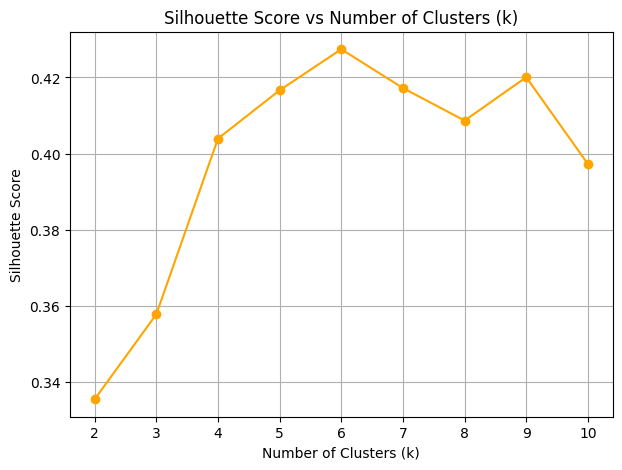


✅ Optimal number of clusters: k = 6
🌟 Best Silhouette Score: 0.4274

Cluster Centers:
         Age  Annual Income (k$)  Spending Score (1-100)
0  41.939394           88.939394               16.969697
1  56.333333           54.266667               49.066667
2  25.250000           25.833333               76.916667
3  32.692308           86.538462               82.128205
4  26.684211           57.578947               47.789474
5  45.523810           26.285714               19.380952

Clustered dataset saved as 'Mall_Customers_Clustered_Optimized.csv'

--- 🔮 Predict Cluster for a New Customer ---

🧾 The new customer belongs to Cluster: 3

Cluster Characteristics:
Age                       32.692308
Annual Income (k$)        86.538462
Spending Score (1-100)    82.128205
Name: 3, dtype: float64


In [18]:
# 📦 Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 🧭 Step 1: Load dataset
df = pd.read_csv("Mall_Customers.csv")

# 🧹 Step 2: Encode categorical features (Gender)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Male=1, Female=0

# 🎯 Step 3: Select relevant features (excluding gender for better clustering)
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# ⚖️ Step 4: Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 📉 Step 5: Find the optimal k using Silhouette Score
K_range = range(2, 11)
best_k = 0
best_silhouette = -1
silhouette_scores = []
inertia = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)

    if sil_score > best_silhouette:
        best_silhouette = sil_score
        best_k = k

# 📊 Plot Silhouette Score trend
plt.figure(figsize=(7,5))
plt.plot(K_range, silhouette_scores, marker='o', color='orange')
plt.title("Silhouette Score vs Number of Clusters (k)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

print(f"\n✅ Optimal number of clusters: k = {best_k}")
print(f"🌟 Best Silhouette Score: {best_silhouette:.4f}")

# 🧮 Step 6: Train final KMeans model
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=20, max_iter=500)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# 🧠 Step 7: Show cluster centers
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)
cluster_summary = pd.DataFrame(centroids, columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])
print("\nCluster Centers:")
print(cluster_summary)

# 💾 Step 8: Save results
df.to_csv("Mall_Customers_Clustered_Optimized.csv", index=False)
print("\nClustered dataset saved as 'Mall_Customers_Clustered_Optimized.csv'")

# 🔮 Step 9: User input prediction
print("\n--- 🔮 Predict Cluster for a New Customer ---")
gender_input = input("Enter Gender (Male/Female): ").strip().lower()
age_input = float(input("Enter Age: "))
income_input = float(input("Enter Annual Income (k$): "))
score_input = float(input("Enter Spending Score (1-100): "))

# Convert gender (not used in clustering, only for reference)
gender_val = 1 if gender_input == "male" else 0

# Prepare input for clustering model
new_customer = pd.DataFrame({
    'Age': [age_input],
    'Annual Income (k$)': [income_input],
    'Spending Score (1-100)': [score_input]
})

# Scale and predict
new_scaled = scaler.transform(new_customer)
cluster_label = kmeans_final.predict(new_scaled)[0]

print(f"\n🧾 The new customer belongs to Cluster: {cluster_label}")
print("\nCluster Characteristics:")
print(cluster_summary.loc[cluster_label])


In [19]:
# 📊 UPDATED CLUSTER INTERPRETATION TABLE

# Include Gender if it’s in the model
if 'Gender' in df.columns:
    cluster_profile = df.groupby('Cluster')[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)
else:
    cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)

# Add count of records per cluster
cluster_profile['Count'] = df['Cluster'].value_counts().sort_index().values
print(cluster_profile)

# Optional: Display neatly in Jupyter Notebook
try:
    from IPython.display import display
    display(cluster_profile)
except:
    pass


         Gender    Age  Annual Income (k$)  Spending Score (1-100)  Count
Cluster                                                                  
0          0.58  41.94               88.94                   16.97     33
1          0.42  56.33               54.27                   49.07     45
2          0.42  25.25               25.83                   76.92     24
3          0.46  32.69               86.54                   82.13     39
4          0.37  26.68               57.58                   47.79     38
5          0.38  45.52               26.29                   19.38     21


,Gender,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,,
0,0.58,41.94,88.94,16.97,33
1,0.42,56.33,54.27,49.07,45
2,0.42,25.25,25.83,76.92,24
3,0.46,32.69,86.54,82.13,39
4,0.37,26.68,57.58,47.79,38
5,0.38,45.52,26.29,19.38,21


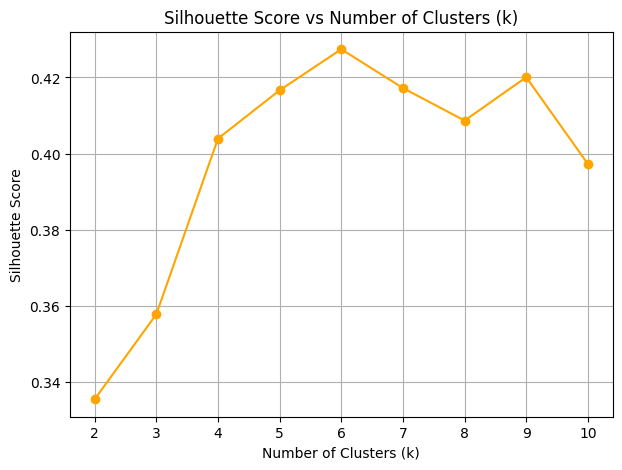


✅ Optimal number of clusters: k = 6
🌟 Best Silhouette Score: 0.4274

Cluster Centers:
         Age  Annual Income (k$)  Spending Score (1-100)
0  41.939394           88.939394               16.969697
1  56.333333           54.266667               49.066667
2  25.250000           25.833333               76.916667
3  32.692308           86.538462               82.128205
4  26.684211           57.578947               47.789474
5  45.523810           26.285714               19.380952

Clustered dataset saved as 'Mall_Customers_Clustered_Optimized.csv'

--- 🔮 Predict Cluster for a New Customer ---

🧾 The new customer belongs to Cluster: 3

Cluster Characteristics:
Age                       32.692308
Annual Income (k$)        86.538462
Spending Score (1-100)    82.128205
Name: 3, dtype: float64

--- 📊 Cluster Interpretation ---
Cluster 0: 💼 Wealthy but Frugal (High Income, Low Spending)
 → Avg Age: 41.9, Income: 88.9k$, Spending Score: 17.0

Cluster 1: 🎯 Average Middle-Class Customers
 → Av

In [20]:
# 📦 Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 🧭 Step 1: Load dataset
df = pd.read_csv("Mall_Customers.csv")

# 🧹 Step 2: Encode categorical features (Gender)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Male=1, Female=0

# 🎯 Step 3: Select relevant features (excluding gender for better clustering)
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# ⚖️ Step 4: Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 📉 Step 5: Find the optimal k using Silhouette Score
K_range = range(2, 11)
best_k = 0
best_silhouette = -1
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    labels = kmeans.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)
    if sil_score > best_silhouette:
        best_silhouette = sil_score
        best_k = k

# 📊 Plot Silhouette Score trend
plt.figure(figsize=(7,5))
plt.plot(K_range, silhouette_scores, marker='o', color='orange')
plt.title("Silhouette Score vs Number of Clusters (k)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

print(f"\n✅ Optimal number of clusters: k = {best_k}")
print(f"🌟 Best Silhouette Score: {best_silhouette:.4f}")

# 🧮 Step 6: Train final KMeans model
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=20, max_iter=500)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# 🧠 Step 7: Show cluster centers
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)
cluster_summary = pd.DataFrame(centroids, columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])
print("\nCluster Centers:")
print(cluster_summary)

# 💾 Step 8: Save results
df.to_csv("Mall_Customers_Clustered_Optimized.csv", index=False)
print("\nClustered dataset saved as 'Mall_Customers_Clustered_Optimized.csv'")

# 🔮 Step 9: User input prediction
print("\n--- 🔮 Predict Cluster for a New Customer ---")
gender_input = input("Enter Gender (Male/Female): ").strip().lower()
age_input = float(input("Enter Age: "))
income_input = float(input("Enter Annual Income (k$): "))
score_input = float(input("Enter Spending Score (1-100): "))

# Convert gender (not used in clustering, only for reference)
gender_val = 1 if gender_input == "male" else 0

# Prepare input for clustering model
new_customer = pd.DataFrame({
    'Age': [age_input],
    'Annual Income (k$)': [income_input],
    'Spending Score (1-100)': [score_input]
})

# Scale and predict
new_scaled = scaler.transform(new_customer)
cluster_label = kmeans_final.predict(new_scaled)[0]

print(f"\n🧾 The new customer belongs to Cluster: {cluster_label}")
print("\nCluster Characteristics:")
print(cluster_summary.loc[cluster_label])

# 🧩 Step 10: Cluster Interpretation
print("\n--- 📊 Cluster Interpretation ---")

for i in range(best_k):
    avg_age = cluster_summary.loc[i, 'Age']
    avg_income = cluster_summary.loc[i, 'Annual Income (k$)']
    avg_score = cluster_summary.loc[i, 'Spending Score (1-100)']

    if avg_income > 70 and avg_score > 60:
        segment = "💎 Premium Customers (High Income, High Spending)"
    elif avg_income > 70 and avg_score < 40:
        segment = "💼 Wealthy but Frugal (High Income, Low Spending)"
    elif avg_income < 40 and avg_score > 60:
        segment = "🛍️ Young Enthusiastic Spenders (Low Income, High Spending)"
    elif avg_income < 40 and avg_score < 40:
        segment = "🧾 Budget-Conscious (Low Income, Low Spending)"
    else:
        segment = "🎯 Average Middle-Class Customers"

    print(f"Cluster {i}: {segment}")
    print(f" → Avg Age: {avg_age:.1f}, Income: {avg_income:.1f}k$, Spending Score: {avg_score:.1f}\n")

# 👤 Step 11: Interpret new customer cluster
print(f"\n🔍 Interpretation for this customer (Cluster {cluster_label}):")

avg_income = cluster_summary.loc[cluster_label, 'Annual Income (k$)']
avg_score = cluster_summary.loc[cluster_label, 'Spending Score (1-100)']

if avg_income > 70 and avg_score > 60:
    interp = "💎 Likely belongs to the Premium Customers group — High Income and High Spending habits."
elif avg_income > 70 and avg_score < 40:
    interp = "💼 Likely a Wealthy but Frugal customer — earns well but spends cautiously."
elif avg_income < 40 and avg_score > 60:
    interp = "🛍️ Young Enthusiastic Spender — lower income but enjoys spending."
elif avg_income < 40 and avg_score < 40:
    interp = "🧾 Budget-Conscious customer — limited income and controlled spending."
else:
    interp = "🎯 Average Middle-Class Customer — balanced income and moderate spending."

print(interp)
